# Notebook 06 - Inférence & Prédictions

## Objectif

Montrer que le modèle final peut être utilisé pour prédire la survie de nouveaux passagers qui n'appartiennent pas au jeu de données d'entraînement.

Ce notebook répond notamment aux questions suivantes :

-   Comment utiliser le modèle entraîné ?
-   Comment préparer de nouvelles données avant une prédiction ?
-   Quelle est la probabilité de survie prédite pour un nouveau passager ?
-   Comment automatiser ce processus ?

## Sommaire

1. Introduction
2. Chargement des biblothèques
3. Chargement du modèle et du scaler
4. Création de nouveaux passagers
5. Préparation automatique des nouvelles données
6. Réalisation des prédictions
7. Création d'une fonction de prédiction
8. Tests sur plusieurs profils
9. Limites d'utilisation
10. Conclusion 


## 1. Introduction 



Après avoir réalisé l'analyse exploratoire, le prétraitement, la modélisation, l'évaluation, l'optimisation et l'interprétation du modèle, ce notebook constitue la dernière étape de la chaîne de modélisation.

L'objectif est de montrer comment utiliser le modèle final de Régression Logistique sur de nouvelles observations qui n'ont jamais été utilisées lors de son entraînement.

Ce notebook permet notamment de :

- recharger le modèle final ;
- recharger le scaler utilisé lors de la modélisation ;
- vérifier les variables attendues par le modèle ;
- construire de nouveaux profils de passagers ;
- appliquer exactement les mêmes transformations que celles utilisées lors de l'entraînement ;
- obtenir une classe prédite ;
- obtenir une probabilité de survie ;
- automatiser la prédiction grâce à une fonction réutilisable ;
- tester différents profils de passagers ;
- analyser les résultats obtenus ;
- identifier les limites de l'utilisation du modèle.

Le modèle utilisé est la Régression Logistique baseline retenue à l'issue du Notebook 04.

## 2. Chargement des bibliothèques 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from joblib import load

from sklearn.linear_model import LogisticRegression

## 3. Chargement du modèle final 

Comme tu as actuellement lr en mémoire, il est possible de l'utiliser directement.

Mais pour un notebook professionnel, il est préférable de montrer que le modèle peut être rechargé depuis un fichier.

In [2]:
# Chargement du modèle final
lr_loaded = load("../models/logistic_regression_baseline.pkl")

print("Type du modèle :", type(lr_loaded))

Type du modèle : <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [3]:
print(lr_loaded)

LogisticRegression(random_state=42)


## 4. Chargement du scaler

In [4]:
scaler_loaded = load("../models/standard_scaler.pkl")

print("Type du scaler :", type(scaler_loaded))

Type du scaler : <class 'sklearn.preprocessing._data.StandardScaler'>


## 5. Définition des variables attendues 

C'est une étape très importante.

Ton modèle attend exactement ces 15 variables :

In [5]:
expected_features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Cabin_known',
    'FamilySize',
    'IsAlone',
    'Embarked_Q',
    'Embarked_S',
    'Title_Miss',
    'Title_Mr',
    'Title_Mrs',
    'Title_Rare'
]

## 6. Vérification du scaler

Le scaler doit également avoir été entraîné sur ces 15 variables.

In [6]:
print(
    "Nombre de variables utilisées par le scaler :",
    scaler_loaded.n_features_in_
)

Nombre de variables utilisées par le scaler : 15


## 7. Vérification de la cohérence du modèle

In [7]:
print(
    "Nombre de coefficients du modèle :",
    len(lr_loaded.coef_[0])
)

Nombre de coefficients du modèle : 15


Nous pouvons également vérifier le nombre de coefficients du modèle.

### Vérification globale

In [8]:
print("Variables attendues :", len(expected_features))
print("Variables du scaler :", scaler_loaded.n_features_in_)
print("Coefficients du modèle :", len(lr_loaded.coef_[0]))

Variables attendues : 15
Variables du scaler : 15
Coefficients du modèle : 15


#### ***Conclusion*** 

Le modèle final, le scaler et la structure des variables sont cohérents.

Les trois éléments reposent sur les mêmes 15 variables explicatives. Cette vérification est essentielle avant toute prédiction afin d'éviter une erreur de dimension ou un mauvais alignement des variables.


## 8. Présentation des variables

On peut créer un petit dictionnaire pour rappeler leur signification.


In [9]:
feature_description = {
    "Pclass": "Classe du passager",
    "Sex": "Sexe encodé : 0 = homme, 1 = femme",
    "Age": "Âge",
    "SibSp": "Nombre de frères/sœurs ou conjoints à bord",
    "Parch": "Nombre de parents/enfants à bord",
    "Fare": "Tarif du billet",
    "Cabin_known": "Cabine connue : 0 = non, 1 = oui",
    "FamilySize": "Taille de la famille à bord",
    "IsAlone": "Passager seul : 0 = non, 1 = oui",
    "Embarked_Q": "Embarquement à Queenstown",
    "Embarked_S": "Embarquement à Southampton",
    "Title_Miss": "Titre Miss",
    "Title_Mr": "Titre Mr",
    "Title_Mrs": "Titre Mrs",
    "Title_Rare": "Titre appartenant aux catégories rares"
}

feature_description

{'Pclass': 'Classe du passager',
 'Sex': 'Sexe encodé : 0 = homme, 1 = femme',
 'Age': 'Âge',
 'SibSp': 'Nombre de frères/sœurs ou conjoints à bord',
 'Parch': 'Nombre de parents/enfants à bord',
 'Fare': 'Tarif du billet',
 'Cabin_known': 'Cabine connue : 0 = non, 1 = oui',
 'FamilySize': 'Taille de la famille à bord',
 'IsAlone': 'Passager seul : 0 = non, 1 = oui',
 'Embarked_Q': 'Embarquement à Queenstown',
 'Embarked_S': 'Embarquement à Southampton',
 'Title_Miss': 'Titre Miss',
 'Title_Mr': 'Titre Mr',
 'Title_Mrs': 'Titre Mrs',
 'Title_Rare': 'Titre appartenant aux catégories rares'}

## 9. Création d'un premier nouveau passager 

Nous allons maintenant créer une observation qui n'a pas servi à entraîner le modèle.

Prenons par exemple :

Femme, 28 ans, première classe, voyageant avec une personne de sa famille, tarif élevé, cabine connue.

In [10]:
passenger_1 = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],
    'Age': [28],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [80],
    'Cabin_known': [1],
    'FamilySize': [2],
    'IsAlone': [0],
    'Embarked_Q': [0],
    'Embarked_S': [1],
    'Title_Miss': [0],
    'Title_Mr': [0],
    'Title_Mrs': [1],
    'Title_Rare': [0]
})

## 10. Vérification de la structure

In [11]:
passenger_1

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,1,28,1,0,80,1,2,0,0,1,0,0,1,0


In [12]:
print(passenger_1.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_known', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [14]:
assert passenger_1.columns.tolist() == expected_features

print("Structure du passager conforme au modèle.")


Structure du passager conforme au modèle.


C'est une bonne pratique professionnelle : si une colonne manque ou est dans le mauvais ordre, le programme s'arrête immédiatement.

## 11. Standardisation

Le scaler doit être celui entraîné précédemment.

On ne doit surtout pas faire : scaler.fit_transform(passenger_1)

In [16]:
passenger_1_scaled = scaler_loaded.transform(
    passenger_1
)



## 12. Vérification du résultat

In [17]:
print(passenger_1_scaled)

[[-1.57145722  1.34693328 -0.11207776  0.47833454 -0.46618317  1.00322394
   1.85741756  0.07341193 -1.24946032 -0.28933346  0.61197825 -0.50350881
  -1.17189306  2.37785736 -0.16104844]]


#### Conversion en DataFrame

Pour faciliter la lecture 

In [18]:
passenger_1_scaled_df = pd.DataFrame(
    passenger_1_scaled,
    columns=expected_features
)

passenger_1_scaled_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,-1.571457,1.346933,-0.112078,0.478335,-0.466183,1.003224,1.857418,0.073412,-1.24946,-0.289333,0.611978,-0.503509,-1.171893,2.377857,-0.161048


## 13. Prédiction de la classe 

In [19]:
prediction = lr_loaded.predict(
    passenger_1_scaled
)

print("Classe prédite :", prediction[0])

Classe prédite : 1


/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## 14. Traduction de la prédiction

Pour rendre le résultat compréhensible :

In [20]:
prediction_label = (
    "Survivant"
    if prediction[0] == 1
    else "Non survivant"
)

print("Prédiction :", prediction_label)

Prédiction : Survivant


## 15. Probabilité de survie

La classe prédite ne suffit pas.

Il est beaucoup plus intéressant de connaître la probabilité associée.

In [21]:
probabilities = lr_loaded.predict_proba(
    passenger_1_scaled
)

print(probabilities)

[[0.03223594 0.96776406]]


/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


le tableau contient : [probabilité classe 0, probabilité classe 1]

In [22]:
survival_probability = probabilities[0, 1]

print(
    f"Probabilité de survie : {survival_probability:.2%}"
)

Probabilité de survie : 96.78%


## 16. Première interprétation

Pour ce profil, le modèle prédit une survie.

La probabilité estimée correspond à la probabilité associée à la classe 1, c'est-à-dire à la survie.

Il convient toutefois de rappeler qu'une probabilité de 91 % ne signifie pas que le passager aurait nécessairement survécu. Elle représente le niveau de confiance probabiliste du modèle compte tenu des caractéristiques fournies.


## 17. Création de plusieurs profils

C'est ici que le notebook devient beaucoup plus intéressant.

Nous allons tester différents profils.

In [23]:
passengers = pd.DataFrame({
    'Pclass': [1, 3, 2, 3],
    'Sex': [1, 0, 1, 0],
    'Age': [28, 45, 8, 65],
    'SibSp': [1, 0, 1, 0],
    'Parch': [0, 0, 1, 0],
    'Fare': [80, 8, 30, 7],
    'Cabin_known': [1, 0, 0, 0],
    'FamilySize': [2, 1, 3, 1],
    'IsAlone': [0, 1, 0, 1],
    'Embarked_Q': [0, 1, 0, 0],
    'Embarked_S': [1, 0, 1, 1],
    'Title_Miss': [0, 0, 1, 0],
    'Title_Mr': [0, 1, 0, 1],
    'Title_Mrs': [1, 0, 0, 0],
    'Title_Rare': [0, 0, 0, 0]
})

## 18. Vérification

In [24]:
assert passengers.columns.tolist() == expected_features

print("Les nouvelles observations sont conformes.")

Les nouvelles observations sont conformes.


## 19. Standardisation des nouveaux passagers

In [25]:
passengers_scaled = scaler_loaded.transform(
    passengers
)

## 20. Prédictions

In [26]:
predictions = lr_loaded.predict(
    passengers_scaled
)

/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## 21. Probabilités

In [27]:
probabilities = lr_loaded.predict_proba(
    passengers_scaled
)[:, 1]

/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## 22. Création du tableau final

In [28]:
results = passengers.copy()

results["Prediction"] = predictions

results["Prediction_Label"] = np.where(
    predictions == 1,
    "Survivant",
    "Non survivant"
)

results["Survival_Probability"] = probabilities

results

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Prediction,Prediction_Label,Survival_Probability
0,1,1,28,1,0,80,1,2,0,0,1,0,0,1,0,1,Survivant,0.967764
1,3,0,45,0,0,8,0,1,1,1,0,0,1,0,0,0,Non survivant,0.087624
2,2,1,8,1,1,30,0,3,0,0,1,1,0,0,0,1,Survivant,0.754102
3,3,0,65,0,0,7,0,1,1,0,1,0,1,0,0,0,Non survivant,0.026853


#### Pourcentage

In [30]:
results["Survival_Probability_%"] = (
    results["Survival_Probability"] * 100
).round(2)



results



,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Prediction,Prediction_Label,Survival_Probability,Survival_Probability_%
0,1,1,28,1,0,80,1,2,0,0,1,0,0,1,0,1,Survivant,0.967764,96.78
1,3,0,45,0,0,8,0,1,1,1,0,0,1,0,0,0,Non survivant,0.087624,8.76
2,2,1,8,1,1,30,0,3,0,0,1,1,0,0,0,1,Survivant,0.754102,75.41
3,3,0,65,0,0,7,0,1,1,0,1,0,1,0,0,0,Non survivant,0.026853,2.69


## 23. Ajouter un identifiant 

In [31]:
results.insert(
    0,
    "Passenger_Profile",
    [
        "Femme - 1ère classe",
        "Homme - 3ème classe",
        "Enfant - 2ème classe",
        "Homme âgé - 3ème classe"
    ]
)

In [32]:
results[
    [
        "Passenger_Profile",
        "Prediction_Label",
        "Survival_Probability_%"
    ]
]

,Passenger_Profile,Prediction_Label,Survival_Probability_%
0,Femme - 1ère classe,Survivant,96.78
1,Homme - 3ème classe,Non survivant,8.76
2,Enfant - 2ème classe,Survivant,75.41
3,Homme âgé - 3ème classe,Non survivant,2.69


## 24. Visualisation des probabilités 

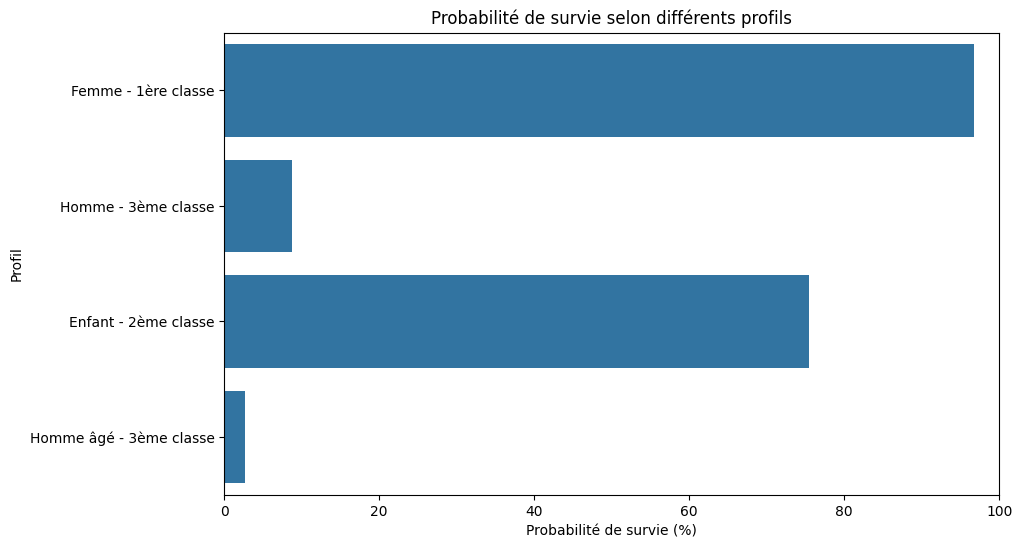

In [33]:
plot_data = results[
    [
        "Passenger_Profile",
        "Survival_Probability_%"
    ]
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Survival_Probability_%",
    y="Passenger_Profile"
)

plt.xlabel("Probabilité de survie (%)")
plt.ylabel("Profil")
plt.title("Probabilité de survie selon différents profils")

plt.xlim(0, 100)

plt.show()

## 25. Fonction réutilisable predict_survival() 

C'est une étape très importante pour l'aspect opérationnel.

Nous voulons éviter de répéter toutes les étapes à chaque nouveau passager.


In [34]:
def predict_survival(passenger, model, scaler):
    
    # Vérification des colonnes
    if list(passenger.columns) != expected_features:
        raise ValueError(
            "Les colonnes fournies ne correspondent pas "
            "aux variables attendues par le modèle."
        )
    
    # Standardisation
    passenger_scaled = scaler.transform(passenger)
    
    # Prédiction
    prediction = model.predict(passenger_scaled)[0]
    
    # Probabilité de survie
    probability = model.predict_proba(
        passenger_scaled
    )[0, 1]
    
    # Traduction
    label = (
        "Survivant"
        if prediction == 1
        else "Non survivant"
    )
    
    return {
        "prediction": prediction,
        "label": label,
        "survival_probability": probability
    }

## 26. Test de la fonction 

In [35]:
result = predict_survival(
    passenger_1,
    lr_loaded,
    scaler_loaded
)

result

/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


{'prediction': np.int64(1),
 'label': 'Survivant',
 'survival_probability': np.float64(0.9677640624058939)}

## 27. Fonction plus lisible

On peut afficher le résultat proprement :

In [36]:
print(
    "Prédiction :", result["label"]
)

print(
    f"Probabilité de survie : "
    f"{result['survival_probability']:.2%}"
)

Prédiction : Survivant
Probabilité de survie : 96.78%


## 28. Test de différents scénarios

Pour ton projet, je te conseille d'ajouter une vraie analyse par scénarios.

### Scénario A — Femme, première classe

In [37]:
scenario_A = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],
    'Age': [30],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [100],
    'Cabin_known': [1],
    'FamilySize': [1],
    'IsAlone': [1],
    'Embarked_Q': [0],
    'Embarked_S': [1],
    'Title_Miss': [0],
    'Title_Mr': [0],
    'Title_Mrs': [1],
    'Title_Rare': [0]
})

### Scénario B — Homme, troisième classe

In [38]:
scenario_B = pd.DataFrame({
    'Pclass': [3],
    'Sex': [0],
    'Age': [30],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [8],
    'Cabin_known': [0],
    'FamilySize': [1],
    'IsAlone': [1],
    'Embarked_Q': [0],
    'Embarked_S': [1],
    'Title_Miss': [0],
    'Title_Mr': [1],
    'Title_Mrs': [0],
    'Title_Rare': [0]
})

### Comparaison

In [39]:
result_A = predict_survival(
    scenario_A,
    lr_loaded,
    scaler_loaded
)

result_B = predict_survival(
    scenario_B,
    lr_loaded,
    scaler_loaded
)

print("Scénario A :", result_A)
print("Scénario B :", result_B)

Scénario A : {'prediction': np.int64(1), 'label': 'Survivant', 'survival_probability': np.float64(0.972353176135024)}
Scénario B : {'prediction': np.int64(0), 'label': 'Non survivant', 'survival_probability': np.float64(0.07319383930755642)}


/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## 29. Analyse des résultats

Cette partie doit être rédigée à partir des résultats réellement obtenus.

Tu ne dois pas écrire avant de connaître les probabilités.

Une fois le code exécuté, tu pourras écrire quelque chose du genre :


Les résultats montrent une différence très importante entre les deux profils étudiés. 

Le premier profil, correspondant à une femme voyageant en première classe, bénéficie de caractéristiques favorables selon le modèle, avec une probabilité de survie estimée à **97,24 %**. 

À l'inverse, le second profil, correspondant à un homme voyageant en troisième classe, présente plusieurs caractéristiques associées à une probabilité de survie plus faible, avec une probabilité estimée à seulement **7,32 %**. 

Cette comparaison illustre la capacité du modèle à combiner plusieurs caractéristiques individuelles pour produire une estimation probabiliste de la survie.


## 30. Analyse de sensibilité simple

Pour rendre le notebook plus intéressant, on peut faire varier une seule variable.
Par exemple, garder le même profil et modifier uniquement Pclass.

In [40]:
scenario_pclass = pd.DataFrame({
    'Pclass': [1, 2, 3],
    'Sex': [0, 0, 0],
    'Age': [30, 30, 30],
    'SibSp': [0, 0, 0],
    'Parch': [0, 0, 0],
    'Fare': [80, 30, 10],
    'Cabin_known': [1, 0, 0],
    'FamilySize': [1, 1, 1],
    'IsAlone': [1, 1, 1],
    'Embarked_Q': [0, 0, 0],
    'Embarked_S': [1, 1, 1],
    'Title_Miss': [0, 0, 0],
    'Title_Mr': [1, 1, 1],
    'Title_Mrs': [0, 0, 0],
    'Title_Rare': [0, 0, 0]
})

In [41]:
pclass_scaled = scaler_loaded.transform(
    scenario_pclass
)

pclass_probabilities = lr_loaded.predict_proba(
    pclass_scaled
)[:, 1]

pclass_results = pd.DataFrame({
    "Pclass": [1, 2, 3],
    "Survival_Probability": pclass_probabilities
})

pclass_results

/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,Pclass,Survival_Probability
0,1,0.503503
1,2,0.146636
2,3,0.073497


## 31. Visualisation

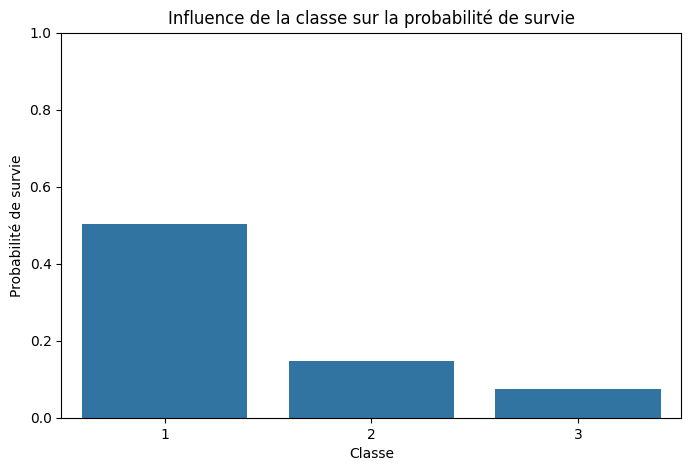

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=pclass_results,
    x="Pclass",
    y="Survival_Probability"
)

plt.ylabel("Probabilité de survie")
plt.xlabel("Classe")
plt.title(
    "Influence de la classe sur la probabilité de survie"
)

plt.ylim(0, 1)

plt.show()

Cela te permettra d'illustrer concrètement les effets du modèle

## 32. Limites de l'inférence

Les prédictions produites dans ce notebook doivent être interprétées avec prudence.

Le modèle a été entraîné sur un jeu de données historique spécifique au Titanic. Ses prédictions sont donc valables uniquement dans le cadre des caractéristiques et de la distribution des données utilisées lors de son entraînement.

La probabilité fournie par le modèle ne représente pas une certitude. Elle constitue une estimation issue du modèle statistique.

Par ailleurs, certaines variables historiques importantes peuvent être absentes du jeu de données. Le modèle ne peut donc pas prendre en compte des facteurs qui ne sont pas présents dans les données.

Enfin, toute nouvelle donnée doit subir exactement les mêmes transformations que les données d'entraînement. L'utilisation d'un scaler différent ou d'un ordre de colonnes incorrect pourrait conduire à des prédictions incohérentes.

## 33. Sauvegarde de la fonction / modèle

Pour la suite du projet, nous allons conserver le modèle et le scaler.

In [43]:
from joblib import dump

dump(
    lr_loaded,
    "../models/logistic_regression_final.pkl"
)

dump(
    scaler_loaded,
    "../models/standard_scaler.pkl"
)

['../models/standard_scaler.pkl']

## 34. Vérification des fichiers

In [44]:
import os

print(
    os.path.exists(
        "../models/logistic_regression_final.pkl"
    )
)

print(
    os.path.exists(
        "../models/standard_scaler.pkl"
    )
)

True
True


## 35. Conclusion générale du Notebook 06


# Conclusion générale

Ce notebook a permis de mettre en œuvre la phase d'inférence du projet Titanic Classification.

À partir du modèle final de Régression Logistique sélectionné lors des étapes précédentes, plusieurs profils de passagers ont été soumis au système de prédiction afin d'obtenir une classe prédite ainsi qu'une probabilité de survie.

Une attention particulière a été portée à la reproductibilité du processus. Les nouvelles observations sont préparées selon la même structure que les données utilisées lors de l'entraînement et standardisées à l'aide du scaler précédemment entraîné. Le modèle et le scaler sont également rechargés depuis leurs fichiers sauvegardés, ce qui permet de reproduire les prédictions indépendamment des notebooks précédents.

La création d'une fonction **`predict_survival()`** permet ensuite de regrouper les différentes étapes du processus dans une fonction réutilisable. Cette approche constitue une première étape vers l'industrialisation du modèle.

Les différents scénarios étudiés montrent comment les caractéristiques d'un passager peuvent modifier la probabilité de survie estimée par le modèle. Ces résultats doivent néanmoins être interprétés comme des estimations probabilistes et non comme des certitudes.

Le projet dispose désormais d'un modèle entraîné, évalué, optimisé, interprété et utilisable sur de nouvelles observations. La prochaine étape consiste à sortir de l'environnement notebook afin de transformer cette solution en un pipeline Machine Learning réutilisable et industrialisable.

## ⚠️ Une correction importante pour ton projet

Il y a une chose que je veux absolument éviter avant de passer au Notebook 07.
Dans ce Notebook 06, nous avons recréé manuellement :

-   Embarked_Q
-   Embarked_S
-   Title_Miss
-   Title_Mr
-   Title_Mrs
-   Title_Rare


et :

-   FamilySize
-   IsAlone
-   Cabin_known

C'est acceptable pour démontrer l'inférence, mais ce n'est pas encore une vraie architecture opérationnelle.

Dans ton futur Notebook 07, nous allons justement corriger cela.







L'objectif sera de passer de :

- Nouvelle donnée
       
       ↓

- création manuelle des variables
       
       ↓

- encodage manuel
       
       ↓

- scaler
       
       ↓
       
- modèle

à : 

-  Nouvelle donnée brute
       
       ↓


-  Pipeline de preprocessing

       ↓

-  Feature Engineering
       
       ↓

-  Encoding
       
       ↓

-  Scaling
       
       ↓

-  Régression Logistique
       
       ↓
       
-  Prédiction